In [ ]:
import numpy as np
import random, time, os
import matplotlib.pyplot as plt

# --- HMM baseline
from hmmlearn import hmm

# --- Metrics
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# --- BayesFlow v2
import bayesflow as bf
from bayesflow.simulators import make_simulator
from bayesflow.adapters import Adapter
from bayesflow.networks import TimeSeriesNetwork, CouplingFlow
from bayesflow.workflows import BasicWorkflow

SEED = 911 #calling for emergency
np.random.seed(SEED)
random.seed(SEED)

AMINO_ACIDS = [
    'A','R','N','D','C','E','Q','G','H','I',
    'L','K','M','F','P','S','T','W','Y','V'
]
AA_TO_IDX = {aa:i for i, aa in enumerate(AMINO_ACIDS)}
N_AA = len(AMINO_ACIDS)

# basic rule for our HMMcase: Start in 'other' (0), alpha=1
STARTPROB = np.array([1.0, 0.0], dtype=float)
TRANSMAT  = np.array([[0.95, 0.05],
                      [0.10, 0.90]], dtype=float)

EMISS_ALPHA = np.array([
    0.12, 0.06, 0.03, 0.05, 0.01, 0.09, 0.05, 0.04, 0.02, 0.07,
    0.12, 0.06, 0.03, 0.04, 0.02, 0.05, 0.04, 0.01, 0.03, 0.06
], dtype=float)

EMISS_OTHER = np.array([
    0.06, 0.05, 0.05, 0.06, 0.02, 0.05, 0.03, 0.09, 0.03, 0.05,
    0.08, 0.06, 0.02, 0.04, 0.06, 0.07, 0.06, 0.01, 0.04, 0.07
], dtype=float)

assert np.allclose(EMISS_ALPHA.sum(), 1.0)
assert np.allclose(EMISS_OTHER.sum(), 1.0)

EMISSIONPROB = np.stack([EMISS_OTHER, EMISS_ALPHA], axis=0)  # (2, 20)

# here we begin!!! bayesflow simulator (returns one-hot X and per-position logits as "parameters")
EPS = 1e-4
SEQ_LEN = 50

def simulate_sequence(T, rng=None):
    rng = np.random.default_rng(rng)
    states = np.empty(T, dtype=int)
    obs    = np.empty(T, dtype=int)
    s = 0  # start in 'other'
    for t in range(T):
        states[t] = s
        obs[t] = rng.choice(N_AA, p=EMISSIONPROB[s])
        s = rng.choice(2, p=TRANSMAT[s])
    return states, obs  # obs are integer-encoded (0..19)

def one_hot_from_int(obs_int):
    return np.eye(N_AA, dtype=np.float32)[obs_int]  # (T, 20)

def simulator(_=None):
    states, obs_int = simulate_sequence(SEQ_LEN)
    x = one_hot_from_int(obs_int)                             # (T, 20) float32
    z = (np.array(states) == 1).astype(np.float32)            # (T,)
    p_alpha = np.clip(z, EPS, 1. - EPS)
    theta   = np.log(p_alpha) - np.log(1.0 - p_alpha)         # logits (T,)
    return {"sim_data": x.astype(np.float32),
            "parameters": theta.astype(np.float32)}

sim = make_simulator(simulator)

adapter = (
    Adapter()
    # .as_time_series("sim_data")              # declare (T,20)
    .concatenate(["sim_data"], into="summary_variables")
    .concatenate(["parameters"], into="inference_variables")
)

# summary_net = TimeSeriesNetwork(
#     hidden_units=[128, 128],
#     pooling="mean",                          # ==> vector per item (stable at sampling)
#     activation="gelu",
# )

import keras
from keras import layers

class SummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.network = keras.Sequential([
            layers.Flatten(),                 # (B, T, 20) -> (B, T*20)
            layers.Dense(256, activation="gelu"),
            layers.Dense(128, activation="gelu"),
            layers.Dense(64,  activation="gelu"),
        ])
    def call(self, x, **kwargs):
        return self.network(x, training=kwargs.get("stage") == "training")
summary_net = SummaryNetwork()

inference_net = CouplingFlow()          # normalizing flow posterior over R^T

workflow = BasicWorkflow(
    simulator=sim,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    initial_learning_rate=1e-3,
)

# ----------------------------
# Offline simulation + training (same API you used)
# ----------------------------
N_TRAIN = 6000
N_VAL   =  600
training_data   = workflow.simulate(N_TRAIN)   # dict with 'summary_variables' and 'inference_variables'
validation_data = workflow.simulate(N_VAL)

history = workflow.fit_offline(
    data=training_data,
    validation_data=validation_data,
    epochs=15,
    steps_per_epoch=100,
    batch_size=32,
    num_batches_per_epoch =200
)


INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 50.6932 - val_loss: 37.2215
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 27.9654 - val_loss: 18.6638
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.5099 - val_loss: -0.5275
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -10.7467 - val_loss: -7.2394
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -19.6672 - val_loss: -18.8729
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -28.3997 - val_loss: -23.0924
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: -35.0780 - val_loss: -30.6486
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -39.5024 - val_loss: -2.0646
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -46.4665 - val_loss: -32.2333
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -48.6846 - val_loss: -18.0643
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -51.5806 - val_loss: -39.7588
Epoch 1

/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


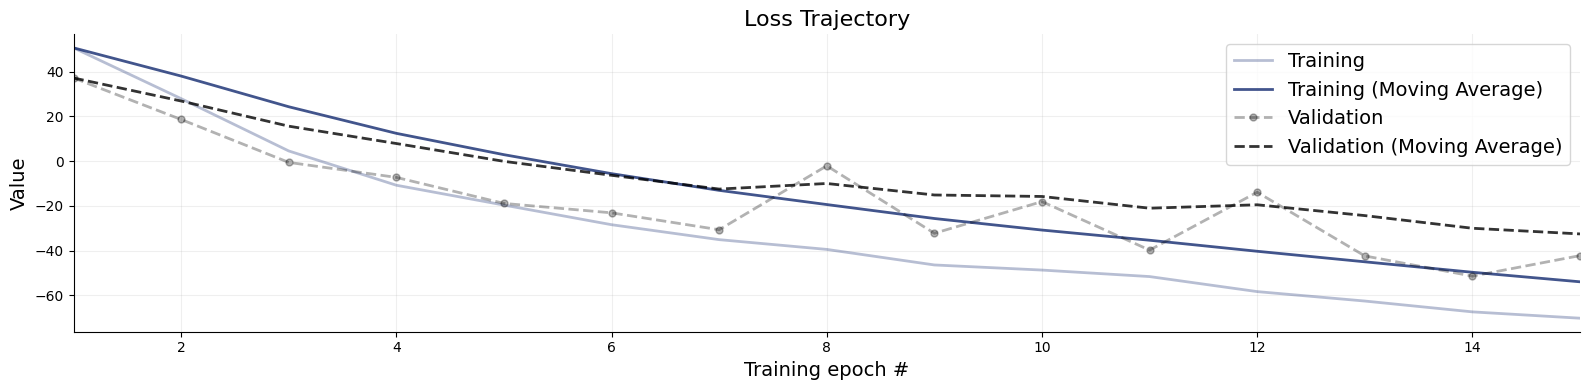

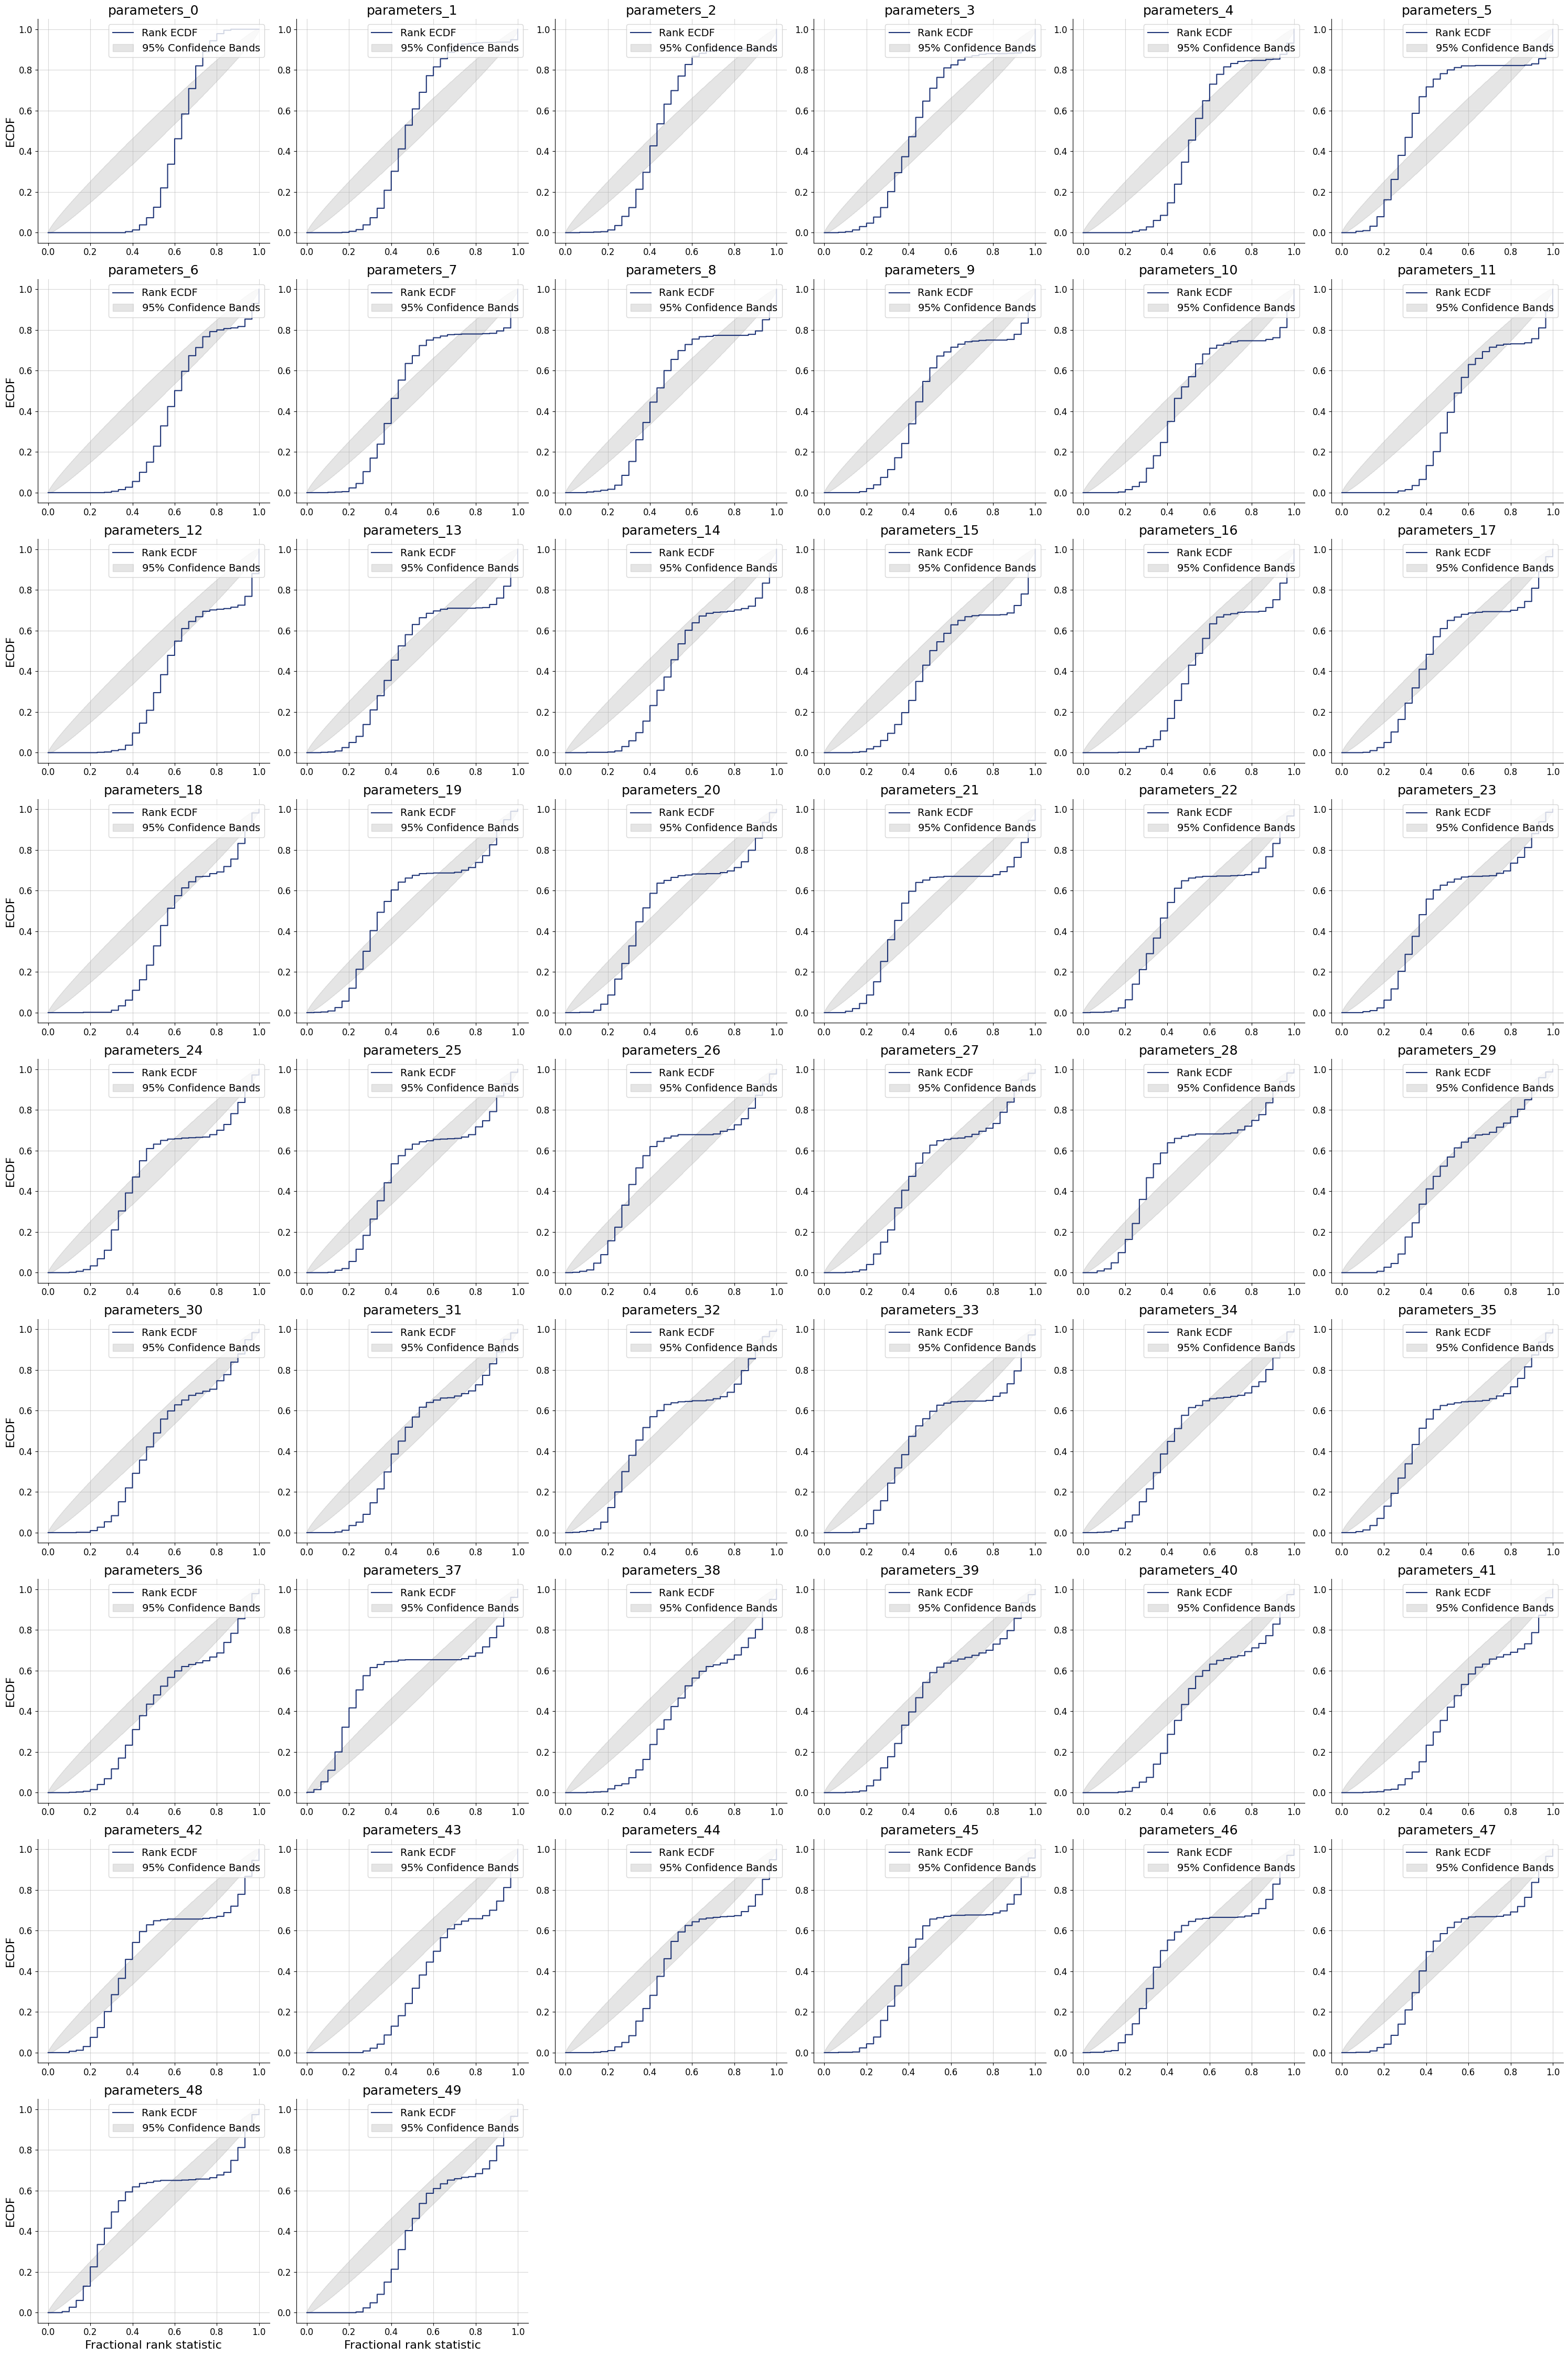

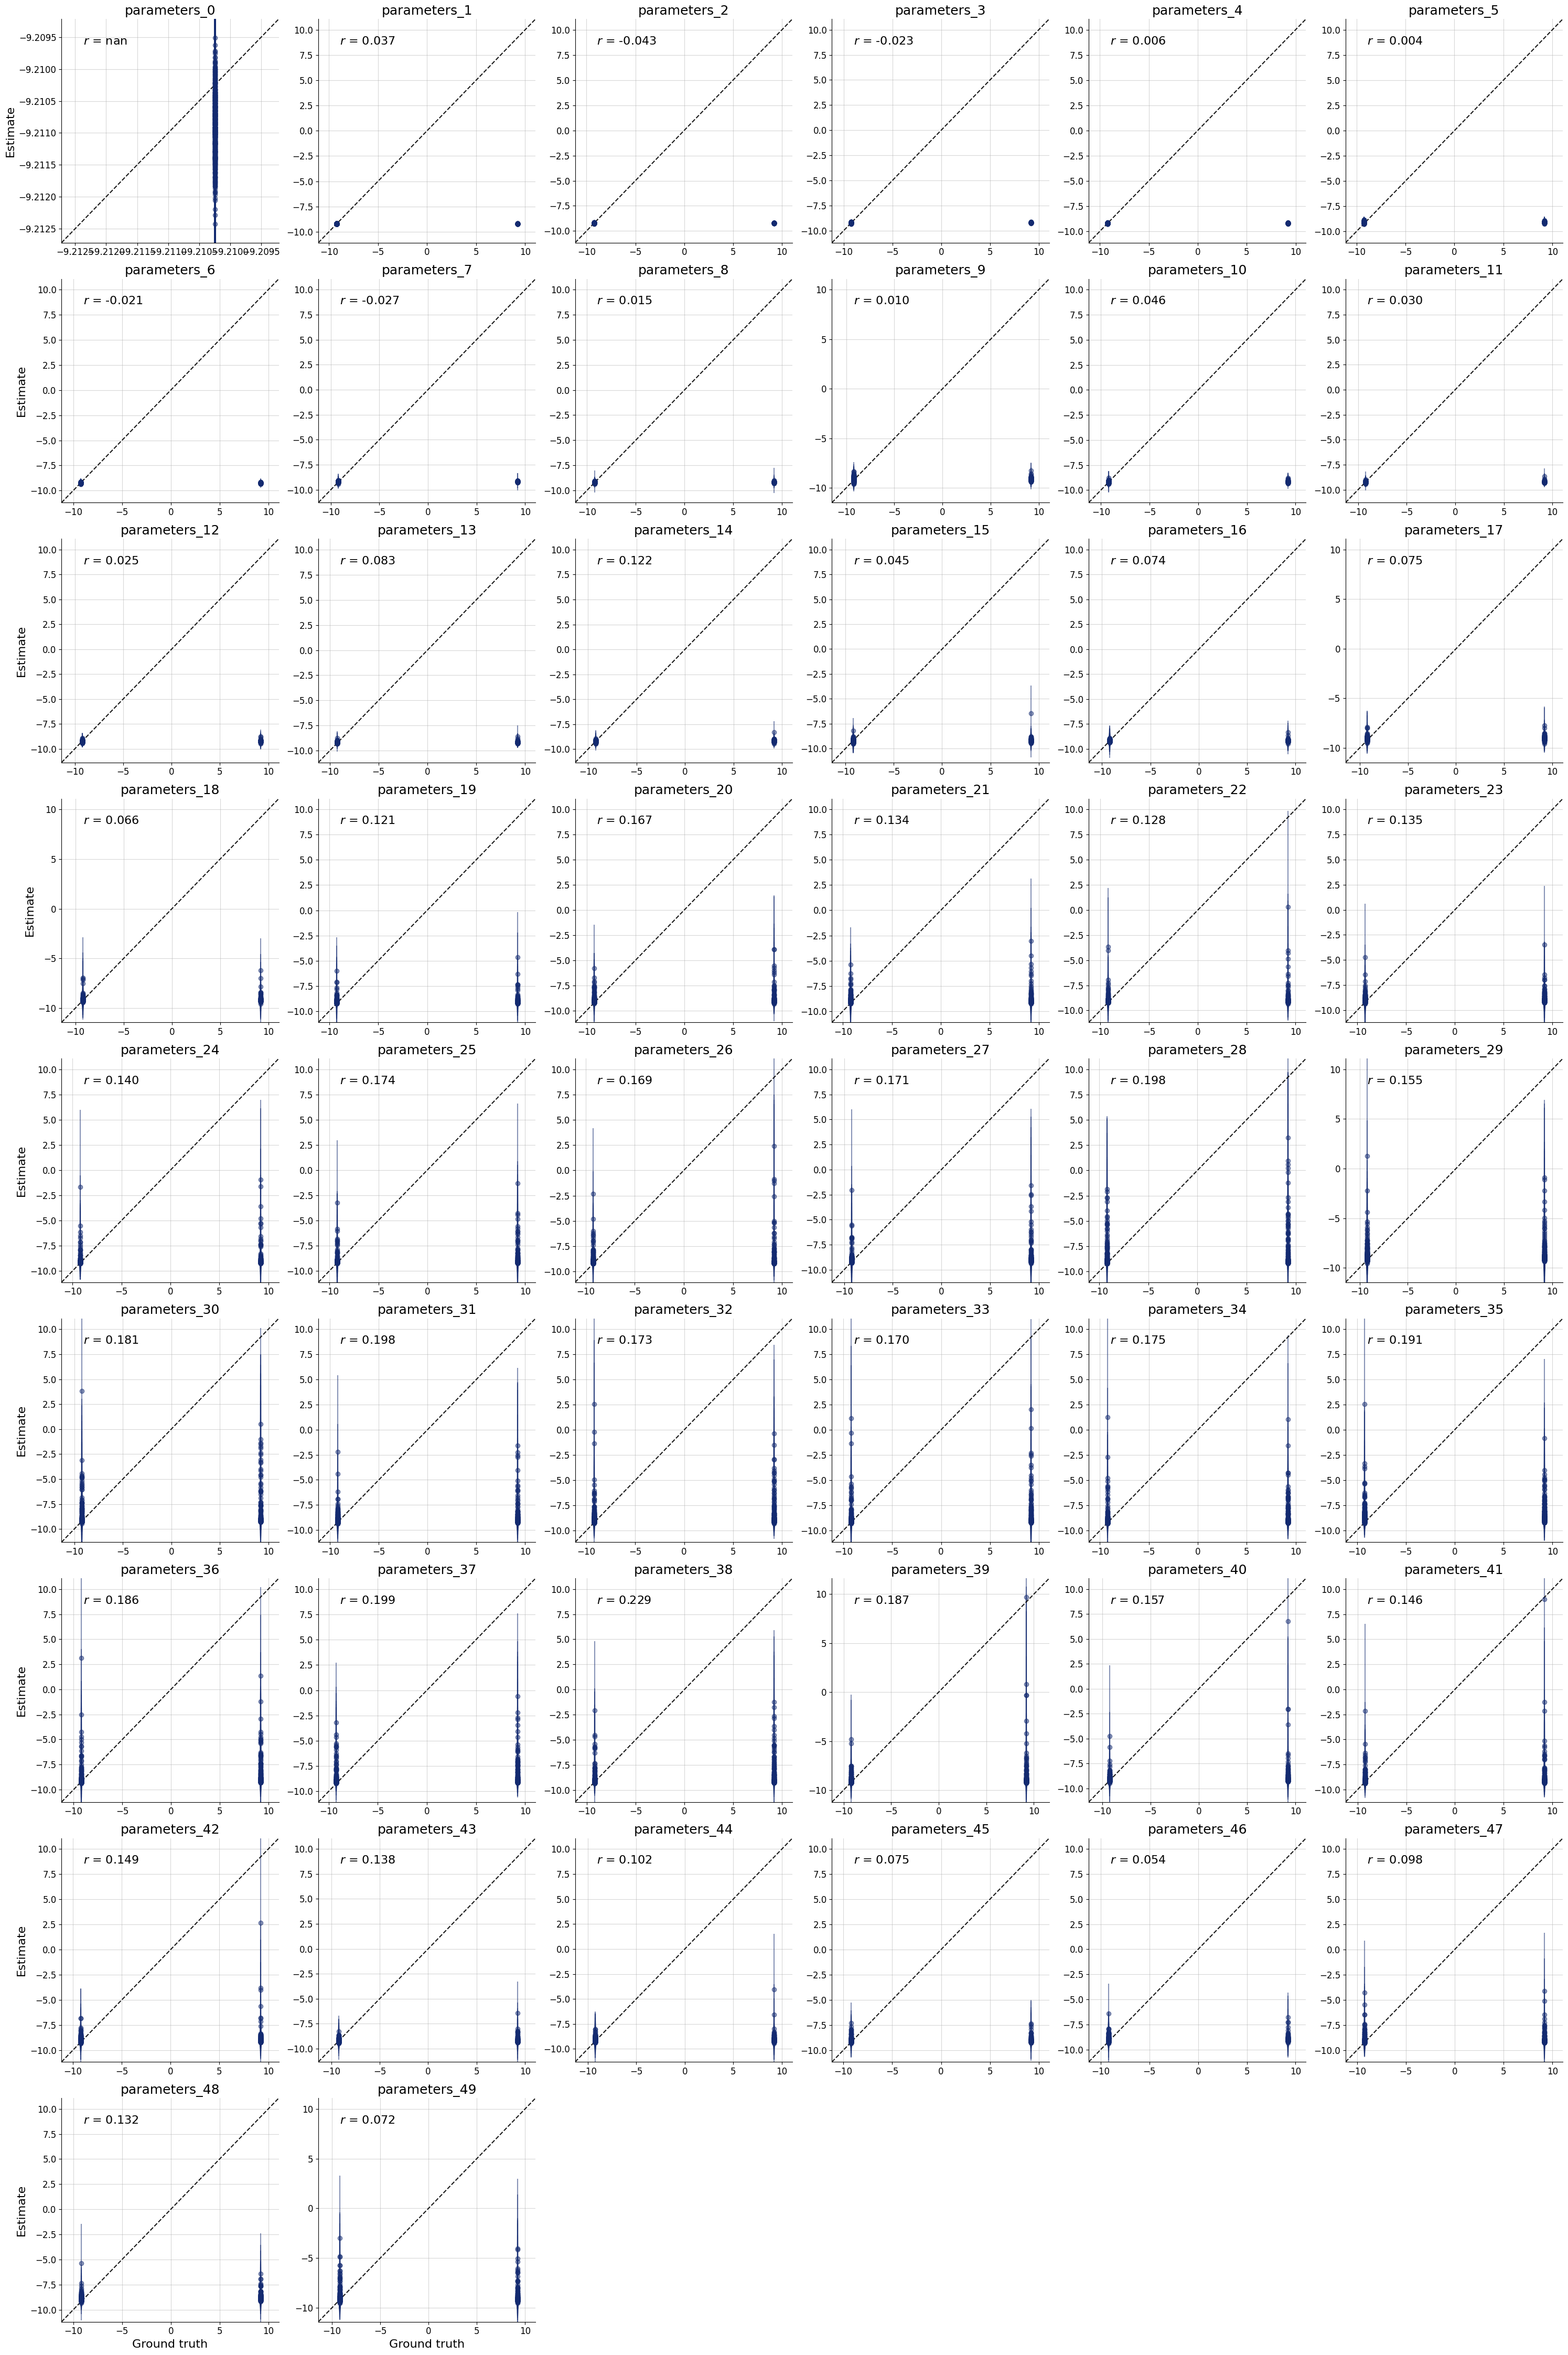

In [11]:
import bayesflow.diagnostics as bf_diag
f = bf_diag.plots.loss(history)
save_valid = validation_data
samples = workflow.sample(conditions=save_valid, num_samples=30)
f1 = bf_diag.plots.calibration_ecdf(samples, save_valid)
f2 = bf_diag.plots.recovery(samples, save_valid)


=== Synthetic single-sequence eval ===
ROC-AUC (FB):  0.4900   (BayesFlow):  0.1433
PR-AUC  (FB):  0.3705   (BayesFlow):  0.2712
ACC@0.5(FB):  0.5400   (BayesFlow):  0.5000


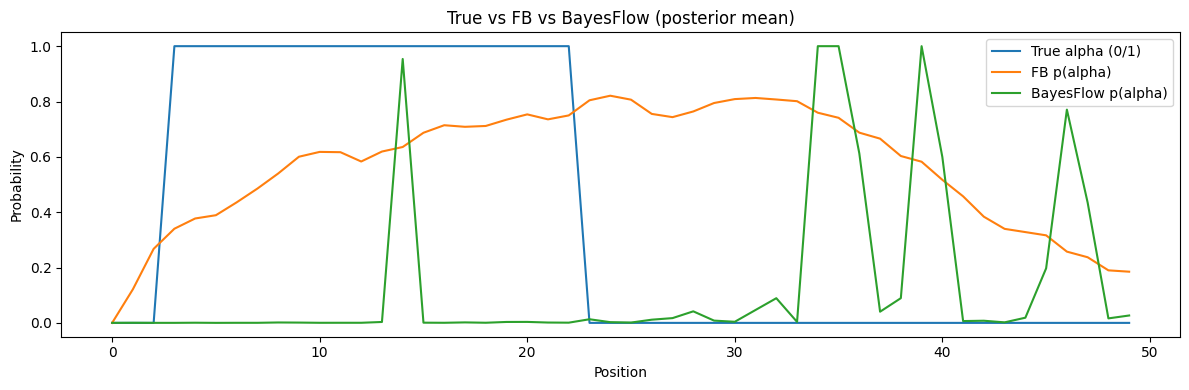

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from hmmlearn import hmm

try:
    workflow
except NameError as _:
    raise RuntimeError("`workflow` is not defined. train/instantiate BayesFlow workflow before running this chunk.")

try:
    sim
except NameError as _:
    raise RuntimeError("`sim` (BayesFlow simulator) is not defined. construct it before running this chunk.")

AMINO_ACIDS = globals().get("AMINO_ACIDS", [
    'A','R','N','D','C','E','Q','G','H','I',
    'L','K','M','F','P','S','T','W','Y','V'
])
AA_TO_IDX = globals().get("AA_TO_IDX", {aa:i for i, aa in enumerate(AMINO_ACIDS)})
N_AA = globals().get("N_AA", len(AMINO_ACIDS))

# HMM params per assignment
STARTPROB = globals().get("STARTPROB", np.array([1.0, 0.0], dtype=float))
TRANSMAT  = globals().get("TRANSMAT",  np.array([[0.95, 0.05],
                                                 [0.10, 0.90]], dtype=float))
if "EMISSIONPROB" in globals():
    EMISSIONPROB = globals()["EMISSIONPROB"]
else:
    EMISS_ALPHA = np.array([
        0.12, 0.06, 0.03, 0.05, 0.01, 0.09, 0.05, 0.04, 0.02, 0.07,
        0.12, 0.06, 0.03, 0.04, 0.02, 0.05, 0.04, 0.01, 0.03, 0.06
    ], dtype=float)
    EMISS_OTHER = np.array([
        0.06, 0.05, 0.05, 0.06, 0.02, 0.05, 0.03, 0.09, 0.03, 0.05,
        0.08, 0.06, 0.02, 0.04, 0.06, 0.07, 0.06, 0.01, 0.04, 0.07
    ], dtype=float)
    assert np.allclose(EMISS_ALPHA.sum(), 1.0), "Alpha emission row must sum to 1"
    assert np.allclose(EMISS_OTHER.sum(), 1.0), "Other emission row must sum to 1"
    EMISSIONPROB = np.stack([EMISS_OTHER, EMISS_ALPHA], axis=0)  # (2,20)

SEQ_LEN = globals().get("SEQ_LEN", 50)

def one_hot_from_int(obs_int):
    return np.eye(N_AA, dtype=np.float32)[np.asarray(obs_int, dtype=int)]


def _make_hmm():
    """Create a fitted-params HMM compatible with hmmlearn version."""
    if hasattr(hmm, "CategoricalHMM"):
        model = hmm.CategoricalHMM(n_components=2, init_params="")
        model.startprob_    = STARTPROB
        model.transmat_     = TRANSMAT
        model.emissionprob_ = EMISSIONPROB
        return model, "categorical"
    else:
        model = hmm.MultinomialHMM(n_components=2, init_params="")
        model.startprob_    = STARTPROB
        model.transmat_     = TRANSMAT
        model.emissionprob_ = EMISSIONPROB
        model.n_trials = 1   # categorical-as-multinomial with one trial
        return model, "multinomial"

def fb_posterior_alpha_from_int(obs_int):
    """
    Return FB posterior P(alpha | x)_t for a single sequence (T,).
    Works with both CategoricalHMM and MultinomialHMM.
    """
    model, kind = _make_hmm()
    obs_int = np.asarray(obs_int, dtype=int)

    if kind == "categorical":
        X = obs_int.reshape(-1, 1)                    # (T,1), integer symbols
    else:  # multinomial: pass one-hot counts with n_trials=1
        X = one_hot_from_int(obs_int).astype(int)     # (T,20), counts sum to 1

    _, post = model.score_samples(X)                  # (T,2)
    return post[:, 1].astype(np.float32)

def fb_posterior_alpha_from_onehot(x_onehot):
    """x_onehot: (T,20) -> FB P(alpha | x)_t (T,)"""
    obs_int = np.argmax(x_onehot, axis=-1)
    return fb_posterior_alpha_from_int(obs_int)

# BayesFlow posterior → per-position probabilities
def _softmax(x, axis=-1):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def _pick_samples_array(samples_dict):
    """Pick the array holding posterior samples, robust to key names."""
    for k in ("inference_variables", "parameters", "posterior", "posterior_samples"):
        if k in samples_dict:
            return samples_dict[k]
    # Fallback: pick the first ndarray-like entry
    for k, v in samples_dict.items():
        if isinstance(v, np.ndarray):
            return v
    raise KeyError(f"No posterior array found. Available keys: {list(samples_dict.keys())}")

def _extract_palpha_from_array(arr, seq_len):
    """
    Convert arbitrary-shaped posterior array to mean p_alpha over samples/draws/batch axes.
    Handles:
      - logits per position: (..., T)
      - 2-class scores per position: (..., T, 2) (either probs or unnormalized scores)
    Returns: (T,) posterior mean p(alpha).
    """
    arr = np.asarray(arr)

    # Identify the time axis by matching seq_len
    axes_with_T = [i for i, s in enumerate(arr.shape) if s == seq_len]
    if not axes_with_T:
        # Fallback: assume last axis is time
        time_axis = arr.ndim - 1
    else:
        time_axis = axes_with_T[-1]  # prefer rightmost T

    # if there is a class axis of size 2 (not the time axis), treat as 2-class scores
    class_axes = [i for i, s in enumerate(arr.shape) if s == 2 and i != time_axis]
    if class_axes:
        cax = class_axes[-1]
        probs = _softmax(arr, axis=cax)        # robust if they are logits; no-op if already probs (up to numerical diff)
        palpha = np.take(probs, indices=1, axis=cax)
        axes_to_mean = tuple(i for i in range(palpha.ndim) if i != time_axis)
        palpha_mean = palpha.mean(axis=axes_to_mean)
        return palpha_mean.astype(np.float32)

    # otherwise assume logits per position
    if time_axis != arr.ndim - 1:
        arr = np.moveaxis(arr, time_axis, -1)  # (..., T)
    logits_mean = arr.mean(axis=tuple(range(arr.ndim - 1))) if arr.ndim > 1 else arr
    palpha = 1.0 / (1.0 + np.exp(-logits_mean))
    return palpha.astype(np.float32)

def bf_posterior_mean_palpha(workflow, x_onehot, num_samples=200, seq_len=SEQ_LEN, verbose_keys=False):
    """
    Given one sequence x (T,20), draw posterior samples and return mean p(alpha)_t (T,).
    Works with either logits-per-position or 2-class-per-position outputs,
    and with various key names for the posterior in samples.
    """
    x = np.asarray(x_onehot, dtype=np.float32)[None, ...]  # (1, T, 20)

    samples = workflow.sample(
        num_samples=num_samples,
        conditions={"summary_variables": x},
    )

    if verbose_keys:
        print("Sample dict keys:", list(samples.keys()))
        try:
            shapes = {k: np.asarray(v).shape for k, v in samples.items() if isinstance(v, np.ndarray)}
            print("Sample array shapes:", shapes)
        except Exception:
            pass

    arr = _pick_samples_array(samples)
    palpha_mean = _extract_palpha_from_array(arr, seq_len=seq_len)
    # Trim to the provided sequence length (handles padding/cropping upstream)
    return palpha_mean[:x_onehot.shape[0]]

# Quick synthetic comparison (one fresh sample)
def synthetic_eval_once(plot=True):
    batch = sim.sample(batch_shape=1)
    x = batch["sim_data"][0]                      # (T,20) one-hot
    # Recover true 0/1 from design where parameters are logits of states
    # (If parameters are not logits, replace with ground-truth labels.)
    states = (batch["parameters"][0] > 0).astype(int)

    # FB baseline
    fb_p = fb_posterior_alpha_from_onehot(x)

    # BayesFlow posterior mean
    bf_p = bf_posterior_mean_palpha(workflow, x, num_samples=200, seq_len=SEQ_LEN)

    # Metrics (guard against degenerate all-0/1 sequences)
    y_true = states.astype(int)
    try:
        auc_fb  = roc_auc_score(y_true, fb_p)
        auc_bf  = roc_auc_score(y_true, bf_p)
        ap_fb   = average_precision_score(y_true, fb_p)
        ap_bf   = average_precision_score(y_true, bf_p)
        acc_fb  = accuracy_score(y_true, (fb_p >= 0.5).astype(int))
        acc_bf  = accuracy_score(y_true, (bf_p >= 0.5).astype(int))
    except ValueError:
        auc_fb = auc_bf = ap_fb = ap_bf = np.nan
        acc_fb = accuracy_score(y_true, (fb_p >= 0.5).astype(int))
        acc_bf = accuracy_score(y_true, (bf_p >= 0.5).astype(int))

    print("\n=== Synthetic single-sequence eval ===")
    print(f"ROC-AUC (FB): {auc_fb: .4f}   (BayesFlow): {auc_bf: .4f}")
    print(f"PR-AUC  (FB): {ap_fb: .4f}   (BayesFlow): {ap_bf: .4f}")
    print(f"ACC@0.5(FB): {acc_fb: .4f}   (BayesFlow): {acc_bf: .4f}")

    if plot:
        t = np.arange(min(len(x), SEQ_LEN))
        plt.figure(figsize=(12, 4))
        plt.plot(t, y_true[:len(t)], label="True alpha (0/1)", linewidth=1.5)
        plt.plot(t, fb_p[:len(t)],   label="FB p(alpha)", linewidth=1.5)
        plt.plot(t, bf_p[:len(t)],   label="BayesFlow p(alpha)", linewidth=1.5)
        plt.ylim(-0.05, 1.05); plt.xlabel("Position"); plt.ylabel("Probability")
        plt.title("True vs FB vs BayesFlow (posterior mean)")
        plt.legend(); plt.tight_layout(); plt.show()

# Run the quick check once
synthetic_eval_once(plot=True)

# Evaluate a real sequence (e.g., insulin) if provided
def aa_seq_to_int(seq):
    seq = seq.strip().upper()
    return np.array([AA_TO_IDX[aa] for aa in seq], dtype=int)

def evaluate_real_sequence(seq_str, true_alpha_binary=None, plot=True, title="Real sequence"):
    obs_int = aa_seq_to_int(seq_str)
    x = one_hot_from_int(obs_int)                  # (T,20)
    # FB at native sequence length
    fb_p = fb_posterior_alpha_from_int(obs_int)
    # Fit BayesFlow conditions to SEQ_LEN (pad/crop) but trim back for plotting
    if len(obs_int) >= SEQ_LEN:
        x_fit = x[:SEQ_LEN]
        trim_back = SEQ_LEN
    else:
        pad = np.eye(N_AA, dtype=np.float32)[np.full(SEQ_LEN - len(obs_int), fill_value=AA_TO_IDX['A'])]
        x_fit = np.concatenate([x, pad], axis=0)
        trim_back = len(obs_int)

    bf_p_full = bf_posterior_mean_palpha(workflow, x_fit, num_samples=200, seq_len=SEQ_LEN)[:trim_back]

    if true_alpha_binary is not None and len(true_alpha_binary) == len(obs_int):
        y_true = true_alpha_binary.astype(int)
        try:
            auc_fb = roc_auc_score(y_true, fb_p)
            auc_bf = roc_auc_score(y_true, bf_p_full)
            ap_fb  = average_precision_score(y_true, fb_p)
            ap_bf  = average_precision_score(y_true, bf_p_full)
            acc_fb = accuracy_score(y_true, (fb_p >= 0.5).astype(int))
            acc_bf = accuracy_score(y_true, (bf_p_full >= 0.5).astype(int))
        except ValueError:
            auc_fb = auc_bf = ap_fb = ap_bf = np.nan
            acc_fb = accuracy_score(y_true, (fb_p >= 0.5).astype(int))
            acc_bf = accuracy_score(y_true, (bf_p_full >= 0.5).astype(int))
        print(f"\n=== {title} ===")
        print(f"ROC-AUC (FB): {auc_fb: .4f}   (BayesFlow): {auc_bf: .4f}")
        print(f"PR-AUC  (FB): {ap_fb: .4f}   (BayesFlow): {ap_bf: .4f}")
        print(f"ACC@0.5(FB): {acc_fb: .4f}   (BayesFlow): {acc_bf: .4f}")
    else:
        print(f"\n=== {title} (no ground truth provided) ===")

    if plot:
        t = np.arange(len(obs_int))
        plt.figure(figsize=(12, 4))
        if true_alpha_binary is not None and len(true_alpha_binary) == len(obs_int):
            plt.plot(t, true_alpha_binary, label="True alpha (0/1)", linewidth=1.5)
        plt.plot(t, fb_p,      label="FB p(alpha)", linewidth=1.5)
        plt.plot(t, bf_p_full, label="BayesFlow p(alpha)", linewidth=1.5)
        plt.ylim(-0.05, 1.05); plt.xlabel("Position"); plt.ylabel("Probability")
        plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

DSSP chains found: {'A': 21, 'B': 29}
Loaded 2 FASTA record(s).


/tmp/ipykernel_685/3793302179.py:117: RuntimeWarning: overflow encountered in exp
  palpha = 1.0 / (1.0 + np.exp(-arr))     # (..., T)
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

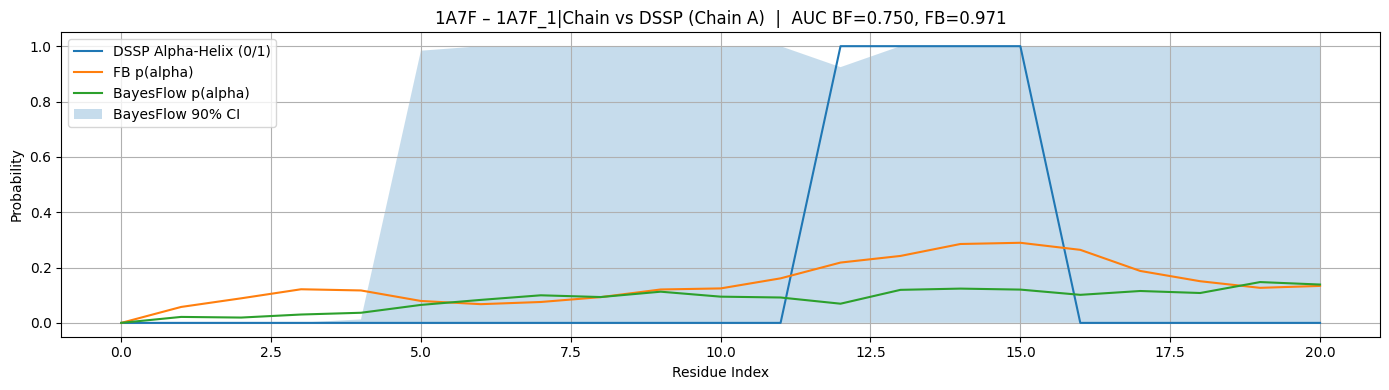

/tmp/ipykernel_685/3793302179.py:117: RuntimeWarning: overflow encountered in exp
  palpha = 1.0 / (1.0 + np.exp(-arr))     # (..., T)
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hamza_wsl/SBI_Proj_hamz/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

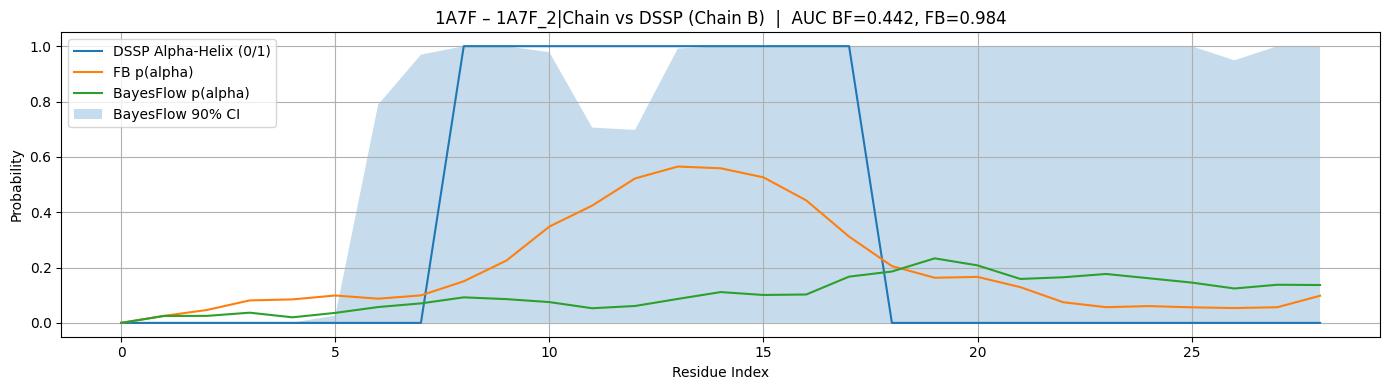

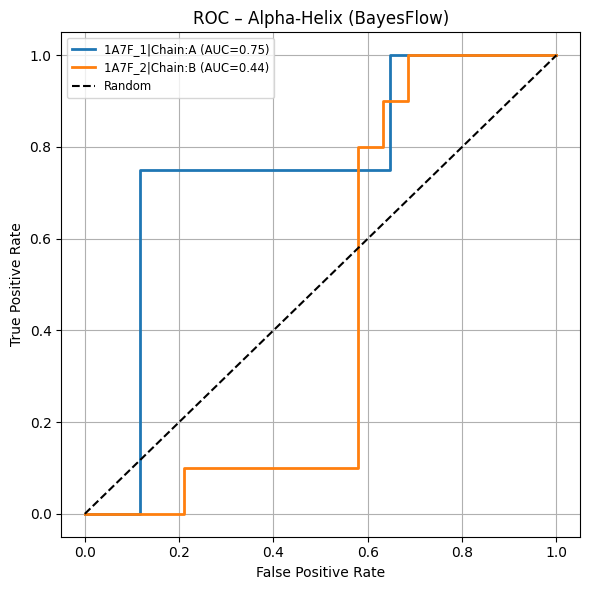


Evaluation for 1A7F_1|Chain (Chain A)
ROC AUC  – BayesFlow: 0.750 | FB: 0.971
PR  AUC  – BayesFlow: 0.425  | FB: 0.887
ACC@0.5 – BayesFlow: 0.810 | FB: 0.810
              precision    recall  f1-score   support

       Other       0.81      1.00      0.89        17
 Alpha-Helix       0.00      0.00      0.00         4

    accuracy                           0.81        21
   macro avg       0.40      0.50      0.45        21
weighted avg       0.66      0.81      0.72        21


Evaluation for 1A7F_2|Chain (Chain B)
ROC AUC  – BayesFlow: 0.442 | FB: 0.984
PR  AUC  – BayesFlow: 0.317  | FB: 0.977
ACC@0.5 – BayesFlow: 0.655 | FB: 0.793
              precision    recall  f1-score   support

       Other       0.66      1.00      0.79        19
 Alpha-Helix       0.00      0.00      0.00        10

    accuracy                           0.66        29
   macro avg       0.33      0.50      0.40        29
weighted avg       0.43      0.66      0.52        29



In [15]:
# Insulin (1A7F) evaluation against DSSP with BayesFlow + FB
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, accuracy_score, average_precision_score
from Bio import SeqIO
from Bio.PDB import PDBParser, DSSP
from hmmlearn import hmm

# Fallbacks and vars (used only if not defined earlier)
AMINO_ACIDS = globals().get("AMINO_ACIDS", [
    'A','R','N','D','C','E','Q','G','H','I',
    'L','K','M','F','P','S','T','W','Y','V'
])
AA_TO_IDX = globals().get("AA_TO_IDX", {aa:i for i, aa in enumerate(AMINO_ACIDS)})
N_AA      = globals().get("N_AA", len(AMINO_ACIDS))
SEQ_LEN   = globals().get("SEQ_LEN", 60)  # model's fixed conditioning length

STARTPROB = globals().get("STARTPROB", np.array([1.0, 0.0], dtype=float))
TRANSMAT  = globals().get("TRANSMAT",  np.array([[0.95, 0.05],
                                                 [0.10, 0.90]], dtype=float))
if "EMISSIONPROB" in globals():
    EMISSIONPROB = globals()["EMISSIONPROB"]
else:
    EMISS_ALPHA = np.array([
        0.12, 0.06, 0.03, 0.05, 0.01, 0.09, 0.05, 0.04, 0.02, 0.07,
        0.12, 0.06, 0.03, 0.04, 0.02, 0.05, 0.04, 0.01, 0.03, 0.06
    ], dtype=float)
    EMISS_OTHER = np.array([
        0.06, 0.05, 0.05, 0.06, 0.02, 0.05, 0.03, 0.09, 0.03, 0.05,
        0.08, 0.06, 0.02, 0.04, 0.06, 0.07, 0.06, 0.01, 0.04, 0.07
    ], dtype=float)
    EMISSIONPROB = np.stack([EMISS_OTHER, EMISS_ALPHA], axis=0)

if "workflow" not in globals():
    raise RuntimeError("`workflow` is not defined. Train/instantiate BayesFlow workflow first.")
if "sim" not in globals():
    raise RuntimeError("`sim` is not defined. Construct BayesFlow simulator first.")

# helpers
def one_hot_from_int(obs_int):
    return np.eye(N_AA, dtype=np.float32)[np.asarray(obs_int, dtype=int)]

def aa_seq_to_int(seq):
    seq = seq.strip().upper()
    idxs = []
    for aa in seq:
        if aa in AA_TO_IDX:
            idxs.append(AA_TO_IDX[aa])
        else:
            # unknown residue -> fall back to 'A' (or skip)
            idxs.append(AA_TO_IDX['A'])
    return np.array(idxs, dtype=int)

# hmmlearn FB helpers
def _make_hmm():
    if hasattr(hmm, "CategoricalHMM"):
        model = hmm.CategoricalHMM(n_components=2, init_params="")
        model.startprob_    = STARTPROB
        model.transmat_     = TRANSMAT
        model.emissionprob_ = EMISSIONPROB
        return model, "categorical"
    else:
        model = hmm.MultinomialHMM(n_components=2, init_params="")
        model.startprob_    = STARTPROB
        model.transmat_     = TRANSMAT
        model.emissionprob_ = EMISSIONPROB
        model.n_trials = 1
        return model, "multinomial"

def fb_posterior_alpha_from_int(obs_int):
    model, kind = _make_hmm()
    obs_int = np.asarray(obs_int, dtype=int)
    if kind == "categorical":
        X = obs_int.reshape(-1, 1)                  # (T,1)
    else:
        X = one_hot_from_int(obs_int).astype(int)   # (T,20)
    _, post = model.score_samples(X)                # (T,2)
    return post[:, 1].astype(np.float32)

# BayesFlow posterior extraction (logits or 2-class)
def _softmax(x, axis=-1):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def _pick_samples_array(samples_dict):
    for k in ("inference_variables", "parameters", "posterior", "posterior_samples"):
        if k in samples_dict:
            return samples_dict[k]
    for k, v in samples_dict.items():
        if isinstance(v, np.ndarray):
            return v
    raise KeyError(f"No posterior array found. Available keys: {list(samples_dict.keys())}")

def _to_palpha_samples(arr, seq_len):
    """Return p_alpha samples as shape (S, T)."""
    arr = np.asarray(arr)
    # find time axis
    axes_with_T = [i for i, s in enumerate(arr.shape) if s == seq_len]
    time_axis = axes_with_T[-1] if axes_with_T else (arr.ndim - 1)
    # check class axis of size 2 (not time)
    class_axes = [i for i, s in enumerate(arr.shape) if s == 2 and i != time_axis]

    # move time to last
    if time_axis != arr.ndim - 1:
        arr = np.moveaxis(arr, time_axis, -1)

    if class_axes:
        # recompute after move
        class_axes = [i for i, s in enumerate(arr.shape) if s == 2 and i != arr.ndim - 1]
        cax = class_axes[-1]
        probs = _softmax(arr, axis=cax)         # (..., T, 2)
        palpha = np.take(probs, indices=1, axis=cax)  # (..., T)
    else:
        # logits -> sigmoid
        palpha = 1.0 / (1.0 + np.exp(-arr))     # (..., T)

    # flatten all leading dims into samples axis
    if palpha.ndim == 1:
        palpha = palpha[None, ...]              # (1, T)
    else:
        palpha = palpha.reshape((-1, palpha.shape[-1]))  # (S, T)
    return palpha.astype(np.float32)

def bf_posterior_samples_palpha(workflow, x_onehot, num_samples=200, seq_len=SEQ_LEN):
    """Return SxT array of p(alpha) samples for a single sequence x (T,20)."""
    x = np.asarray(x_onehot, dtype=np.float32)[None, ...]  # (1, T, 20)
    samples = workflow.sample(num_samples=num_samples, conditions={"summary_variables": x})
    arr = _pick_samples_array(samples)
    palpha_samples = _to_palpha_samples(arr, seq_len=seq_len)  # (S, T_pad)
    # trim to provided length (handles padding when T < SEQ_LEN)
    return palpha_samples[:, :x_onehot.shape[0]]

# File paths
fasta_path = "rcsb_pdb_1A7F.fasta"   # FASTA with A/B chains is typical
pdb_path   = "1a7f.pdb"              # PDB file for DSSP (requires 'mkdssp' installed) # mention in report it was too hectic to install

# Build DSSP chain → (sequence, alpha_mask) dict
parser = PDBParser(QUIET=True)
structure = parser.get_structure("INSULIN", pdb_path)

try:
    dssp = DSSP(structure[0], pdb_path)  # requires mkdssp in PATH
except Exception as e:
    raise RuntimeError(
        f"DSSP failed. Ensure 'mkdssp' is installed and in PATH. Original error: {e}"
    )

dssp_chains = {}
for key in dssp.keys():
    chain_id = key[0]
    aa_one   = dssp[key][1]
    ss_char  = dssp[key][2]
    if aa_one == 'X':  # unknown, skip
        continue
    if chain_id not in dssp_chains:
        dssp_chains[chain_id] = {"aa_seq": [], "ss_labels": []}
    dssp_chains[chain_id]["aa_seq"].append(aa_one)
    dssp_chains[chain_id]["ss_labels"].append(1 if ss_char == 'H' else 0)

for c in dssp_chains:
    dssp_chains[c]["aa_seq"]   = "".join(dssp_chains[c]["aa_seq"])
    dssp_chains[c]["ss_labels"] = np.array(dssp_chains[c]["ss_labels"], dtype=int)

print("DSSP chains found:", {c: len(dssp_chains[c]['aa_seq']) for c in dssp_chains})

# Load FASTA records (RCSB provides A and B as separate entries)
records = list(SeqIO.parse(fasta_path, "fasta"))
print(f"Loaded {len(records)} FASTA record(s).")

# Evaluate each FASTA record against matching DSSP chain
roc_data = []
evaluation_results = []

def pad_or_crop_x(x_chain, seq_len=SEQ_LEN):
    """Pad/crop one-hot sequence (L,20) to (SEQ_LEN,20) for BayesFlow conditioning."""
    L = x_chain.shape[0]
    if L >= seq_len:
        return x_chain[:seq_len]
    pad = np.zeros((seq_len - L, N_AA), dtype=np.float32)
    return np.concatenate([x_chain, pad], axis=0)

for rec in records:
    raw_seq = str(rec.seq).strip().upper()
    matched_any = False

    for chain_id, info in dssp_chains.items():
        dssp_seq = info["aa_seq"]
        true_y   = info["ss_labels"]              # (L,)
        L        = len(true_y)

        # try exact match or substring (RCSB FASTA usually matches chain sequences)
        pos = raw_seq.find(dssp_seq)
        if pos == -1:
            # sometimes FASTA record is exactly the chain
            if raw_seq == dssp_seq:
                pos = 0
            else:
                continue  # try next chain

        matched_any = True
        # Prepare inputs
        chain_seq = dssp_seq
        obs_int   = aa_seq_to_int(chain_seq)
        x_chain   = one_hot_from_int(obs_int)     # (L, 20)

        # FB baseline on native length
        fb_p = fb_posterior_alpha_from_int(obs_int)   # (L,)

        # BayesFlow posterior on padded/cropped sequence, then trim to L
        x_fit = pad_or_crop_x(x_chain, SEQ_LEN)
        palpha_samples = bf_posterior_samples_palpha(workflow, x_fit, num_samples=200, seq_len=SEQ_LEN)  # (S, T_fit)
        palpha_samples = palpha_samples[:, :L]    # (S, L)
        palpha_mean = palpha_samples.mean(axis=0)
        ci_low  = np.percentile(palpha_samples, 5, axis=0)
        ci_high = np.percentile(palpha_samples, 95, axis=0)

        # Metrics (guard against degenerate labels)
        if len(np.unique(true_y)) >= 2:
            auc_bf = roc_auc_score(true_y, palpha_mean)
            auc_fb = roc_auc_score(true_y, fb_p)
            ap_bf  = average_precision_score(true_y, palpha_mean)
            ap_fb  = average_precision_score(true_y, fb_p)
            acc_bf = accuracy_score(true_y, (palpha_mean >= 0.5).astype(int))
            acc_fb = accuracy_score(true_y, (fb_p >= 0.5).astype(int))
        else:
            auc_bf = auc_fb = ap_bf = ap_fb = np.nan
            acc_bf = accuracy_score(true_y, (palpha_mean >= 0.5).astype(int))
            acc_fb = accuracy_score(true_y, (fb_p >= 0.5).astype(int))

        report = classification_report(true_y, (palpha_mean >= 0.5).astype(int),
                                       target_names=["Other", "Alpha-Helix"])

        # Store ROC curve for BayesFlow
        try:
            fpr, tpr, _ = roc_curve(true_y, palpha_mean)
            roc_data.append({"record_id": rec.id, "chain_id": chain_id, "fpr": fpr, "tpr": tpr, "auc": auc_bf})
        except ValueError:
            pass

        evaluation_results.append({
            "record_id": rec.id,
            "chain_id": chain_id,
            "roc_auc_bf": auc_bf,
            "roc_auc_fb": auc_fb,
            "ap_bf": ap_bf,
            "ap_fb": ap_fb,
            "acc_bf": acc_bf,
            "acc_fb": acc_fb,
            "report": report
        })

        # ---- Plot per-chain overlay: True vs FB vs BayesFlow ----
        t = np.arange(L)
        plt.figure(figsize=(14, 4))
        plt.plot(t, true_y, label="DSSP Alpha-Helix (0/1)", linewidth=1.5)
        plt.plot(t, fb_p,   label="FB p(alpha)", linewidth=1.5)
        plt.plot(t, palpha_mean, label="BayesFlow p(alpha)", linewidth=1.5)
        plt.fill_between(t, ci_low, ci_high, alpha=0.25, label="BayesFlow 90% CI")
        plt.ylim(-0.05, 1.05)
        plt.title(f"1A7F – {rec.id} vs DSSP (Chain {chain_id})  |  AUC BF={auc_bf:.3f}, FB={auc_fb:.3f}")
        plt.xlabel("Residue Index"); plt.ylabel("Probability")
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    if not matched_any:
        # Show BayesFlow posterior for the FASTA record (no DSSP match)
        obs_int = aa_seq_to_int(raw_seq)
        x_full  = one_hot_from_int(obs_int)
        x_fit   = pad_or_crop_x(x_full, SEQ_LEN)
        palpha_samples = bf_posterior_samples_palpha(workflow, x_fit, num_samples=200, seq_len=SEQ_LEN)
        L = len(raw_seq)
        palpha_mean = palpha_samples.mean(axis=0)[:L]
        ci_low  = np.percentile(palpha_samples, 5, axis=0)[:L]
        ci_high = np.percentile(palpha_samples, 95, axis=0)[:L]

        t = np.arange(L)
        print(f"⚠ No DSSP match found for {rec.id}. Showing BayesFlow posterior only.")
        plt.figure(figsize=(14, 4))
        plt.plot(t, palpha_mean, label="BayesFlow p(alpha)", linewidth=1.5)
        plt.fill_between(t, ci_low, ci_high, alpha=0.25, label="BayesFlow 90% CI")
        plt.ylim(-0.05, 1.05)
        plt.title(f"1A7F – {rec.id}: BayesFlow posterior (no DSSP match)")
        plt.xlabel("Residue Index"); plt.ylabel("Probability")
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ROC summary (BayesFlow curves)
if roc_data:
    plt.figure(figsize=(6, 6))
    for r in roc_data:
        plt.plot(r["fpr"], r["tpr"], lw=2, label=f"{r['record_id']}:{r['chain_id']} (AUC={r['auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC – Alpha-Helix (BayesFlow)")
    plt.legend(fontsize="small"); plt.grid(True); plt.tight_layout(); plt.show()

# ----------------------------
# Text reports
# ----------------------------
for res in evaluation_results:
    print("\n" + "="*70)
    print(f"Evaluation for {res['record_id']} (Chain {res['chain_id']})")
    print(f"ROC AUC  – BayesFlow: {res['roc_auc_bf']:.3f} | FB: {res['roc_auc_fb']:.3f}")
    print(f"PR  AUC  – BayesFlow: {res['ap_bf']:.3f}  | FB: {res['ap_fb']:.3f}")
    print(f"ACC@0.5 – BayesFlow: {res['acc_bf']:.3f} | FB: {res['acc_fb']:.3f}")
    print(res["report"])
